# Introduction

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import SelectPercentile
from time import time
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
import joblib

In [2]:
test_idf = pd.read_excel(r"C:\Users\Utilisateur\Desktop\Master ULB\Mémoire\Thesis - Code\final_df_final.xlsx")

# Comparison

In [3]:
#Configuration of the comparison - we use the full features dataset
features = [key for key in test_idf.columns if 'feature' in key] #All the features in a list 
filtered_list = [key for key in features if 'context' not in key] #The features without the contextual one in another

##NBA-inspired styling
nba_palette = ['#1D428A', '#C8102E', '#FDB927', '#000000', '#007A33']
court_color = '#F5F5F5'
##Create a database that stores the values of AUC, F1, Accuracy (Test & Train) for the three logistic regression models to be able to compare them 
models = {
    'logistic' : LogisticRegression(max_iter=1000, random_state=42),
    'xgb' : XGBClassifier(eval_metric='auc', 
                          random_state=42),
    'svc' : SVC(probability=True, kernel='rbf', random_state=42)
}

##Create the variables
X_f_s = test_idf[features]
scaler = StandardScaler()
X_f_s = scaler.fit_transform(X_f_s)
y_f_s = test_idf['med_tresh']

auc = []
f1 = []
test_acc = []
train_acc = []
name = []

## ANOVA

In [ ]:
# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X_f_s, y_f_s, test_size=0.2, 
                                                    random_state=42, stratify=y_f_s)

percentile_thresholds = [0.05, 0.25,  
                         0.5, 1]
for model_name, model in models.items():
    clf = model
    for i in percentile_thresholds:
        select = SelectPercentile(percentile=i)
        select.fit(X_train, y_train)
        # transform training set
        X_train_selected = select.transform(X_train)
        # transform test data
        X_test_selected = select.transform(X_test)

        clf.fit(X_train_selected, y_train)
        y_train_pred = clf.predict(X_train_selected)
        y_test_pred = clf.predict(X_test_selected)
        y_test_prob = clf.predict_proba(X_test_selected)[:, 1]
        # Étape 5 : métriques
        train_acc.append(accuracy_score(y_train, y_train_pred))
        test_acc.append(accuracy_score(y_test, y_test_pred))
        auc.append(roc_auc_score(y_test, y_test_prob))
        f1.append(f1_score(y_test, y_test_pred))
        name.append(f'anova_{i}_threshold_{model_name}')

## PCA

In [18]:
X_f_s

array([[ 0.75139309,  0.51960842,  0.87799418, ...,  0.62272574,
        -1.87796227,  1.99875169],
       [-0.18647712, -0.01599212,  0.87799418, ..., -0.50299453,
        -0.30378801, -1.10135297],
       [-0.18647712, -0.0983922 , -1.13895971, ..., -0.50299453,
        -0.30378801, -1.10135297],
       ...,
       [ 0.12614629,  2.99161089,  0.87799418, ...,  1.74844601,
        -0.30378801,  1.99875169],
       [ 0.43876969,  0.31360821,  0.87799418, ..., -1.62871479,
        -0.30378801, -2.6514053 ],
       [-0.81172392, -0.71639282, -1.13895971, ..., -0.50299453,
        -0.30378801,  0.44869936]], shape=(912, 8415))

In [19]:
rank = np.linalg.matrix_rank(X_f_s)
print(f"Rang de X : {rank}")

Rang de X : 723


In [23]:
# Étape 3 : entraînement
var_thresholds = [0.9, 0.95, 0.99] #We test 3 thresholds 



for i in var_thresholds:
    pca = PCA(n_components=i, random_state=42)
    X_pca = pca.fit_transform(X_f_s)
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y_f_s, test_size=0.2, 
                                                        random_state=42, stratify=y_f_s)
    for model_name, model in models.items():
        clf = model 
        clf.fit(X_train, y_train)
        y_train_pred = clf.predict(X_train)
        y_test_pred = clf.predict(X_test)
        y_test_prob = clf.predict_proba(X_test)[:, 1]
        # Étape 5 : métriques
        train_acc.append(accuracy_score(y_train, y_train_pred))
        test_acc.append(accuracy_score(y_test, y_test_pred))
        auc.append(roc_auc_score(y_test, y_test_prob))
        f1.append(f1_score(y_test, y_test_pred))
        name.append(f'pca_{i}_threshold_{model_name}')


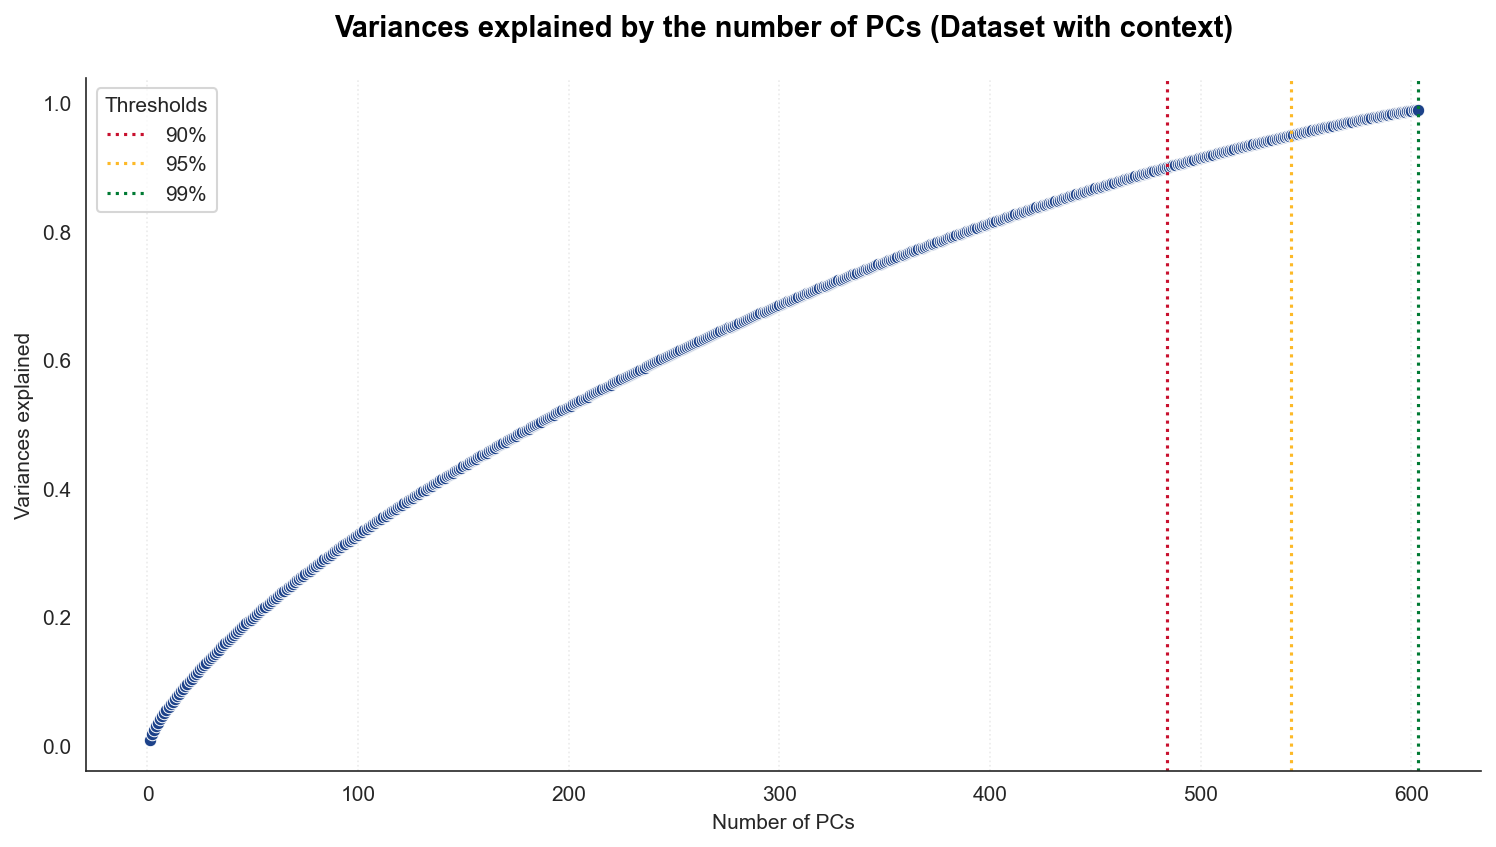

In [24]:
#pca = PCA(n_components=None, random_state=42)
#X_pca = pca.fit_transform(X_f_s)

# 4. Calcul de la variance expliquée
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
# 5. Affichage du graphique
plt.figure(figsize=(12, 6), dpi=150)
sns.set_style('white')
sns.scatterplot(x=range(1, len(cumulative_variance) + 1), y=cumulative_variance, color=nba_palette[0])
plt.title("Variances explained by the number of PCs (Dataset with context)",
          fontsize=14, fontweight='bold', pad=20, color='black')
plt.xlabel("Number of PCs")
plt.ylabel("Variances explained")
plt.grid(axis='x', linestyle=':', alpha=0.4)
plt.axvline(x=np.argmax(cumulative_variance >= 0.9
                        ) + 1, color=nba_palette[1], linestyle=':', label='90%')
plt.axvline(x=np.argmax(cumulative_variance >= 0.95
                        ) + 1, color=nba_palette[2], linestyle=':', label='95%')
plt.axvline(x=np.argmax(cumulative_variance >= 0.99
                        ) + 1, color=nba_palette[4], linestyle=':', label='99%')
plt.legend(title='Thresholds')
sns.despine()
plt.show()


## SelecFromModel

In [ ]:
# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X_f_s, y_f_s, test_size=0.2, 
                                                    random_state=42, stratify=y_f_s)

#Choose estimators
estimators = {
    'logistic' : LogisticRegression(max_iter=1000, random_state=42),
    'xgb' : XGBClassifier(use_label_encoder=False, 
                          eval_metric='auc', random_state=42),
    'randomforest' : RandomForestClassifier(random_state=42)
}
# Pipeline de sélection + modèle
for model_name, model in models.items():
    clf = model
    for estimator_name, estimator in estimators.items():
        pipeline = Pipeline([
            ('feature_selection', SelectFromModel(estimator=estimator)),
            ('classifier', clf)
        ])

        # Grille de recherche
        param_dist = {
            'feature_selection__max_features': Integer(10, 90),  # Seuils basés sur l'importance
        }

        # Randomized Search
        search = BayesSearchCV(
            pipeline,
            search_spaces=param_dist,
            n_iter=100,
            cv=StratifiedKFold(3),
            scoring='roc_auc',
            random_state=42,
            verbose=0,
            n_jobs=-1
        )

        # Entraînement
        search.fit(X_train, y_train)

        # Prédictions
        y_pred = search.predict(X_test)
        y_proba = search.predict_proba(X_test)[:, 1]
        y_train_pred = search.predict(X_train)

        # Résultats
        print("Best threshold selected:", search.best_params_['feature_selection__max_features'])
        train_acc.append(accuracy_score(y_train, y_train_pred))
        test_acc.append(accuracy_score(y_test, y_pred))
        auc.append(roc_auc_score(y_test, y_proba))
        f1.append(f1_score(y_test, y_pred))
        name.append(f'{estimator_name}_{model_name}')


# Comparison

In [25]:
comparison_f_s = {
    'Feature Selection method': name,
    'Train Accuracy' : train_acc,
    'Test Accuracy' : test_acc,
    'F1' : f1,
    'AUC': auc
}

pd.DataFrame(comparison_f_s)

,Feature Selection method,Train Accuracy,Test Accuracy,F1,AUC
0,anova_0.05_threshold_logistic,0.740741,0.726776,0.840764,0.477623
1,anova_0.25_threshold_logistic,0.750343,0.743169,0.849840,0.788580
2,anova_0.5_threshold_logistic,0.766804,0.737705,0.843137,0.734722
3,anova_1_threshold_logistic,0.810700,0.721311,0.825939,0.702160
4,anova_0.05_threshold_xgb,0.740741,0.737705,0.849057,0.500000
5,anova_0.25_threshold_xgb,1.000000,0.743169,0.840678,0.652315
6,anova_0.5_threshold_xgb,1.000000,0.770492,0.860000,0.685340
7,anova_1_threshold_xgb,1.000000,0.765027,0.853242,0.694444
8,anova_0.05_threshold_svc,0.740741,0.737705,0.849057,0.500000
9,anova_0.25_threshold_svc,0.761317,0.737705,0.847134,0.692130
